In [1]:
!nvidia-smi

Sat Jun 27 10:04:55 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.159.04             Driver Version: 580.159.04     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   36C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
!pip install -q ultralytics supervision pandas matplotlib seaborn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.0/41.0 kB 2.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.9/79.9 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 46.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 280.2/280.2 kB 21.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.7/102.7 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 99.3 MB/s eta 0:00:00:00:010:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu1

In [3]:
from ultralytics import YOLO
import os
import yaml
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import supervision as sv

import ultralytics
ultralytics.checks()

Ultralytics 8.4.80 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
Setup complete ✅ (4 CPUs, 31.3 GB RAM, 6960.4/8062.4 GB disk)


In [4]:
from pathlib import Path
import os

# Cek isi folder input Kaggle
input_path = Path("/kaggle/input")

for path in input_path.glob("*"):
    print(path)

/kaggle/input/datasets


In [5]:
yaml_files = list(Path("/kaggle/input").rglob("data.yaml"))

print("Found data.yaml:")
for y in yaml_files:
    print(y)

Found data.yaml:
/kaggle/input/datasets/gibranariq/final-project/final_project.yolo/data.yaml


In [6]:
DATA_YAML = yaml_files[0]
print(DATA_YAML)

/kaggle/input/datasets/gibranariq/final-project/final_project.yolo/data.yaml


In [7]:
import yaml

with open(DATA_YAML, "r") as f:
    data_config = yaml.safe_load(f)

data_config

{'train': '../train/images',
 'val': '../valid/images',
 'test': '../test/images',
 'nc': 2,
 'names': ['awake', 'drowsy'],
 'roboflow': {'workspace': 'gibran-ariq-n',
  'project': 'final_project-akkei',
  'version': 12,
  'license': 'CC BY 4.0',
  'url': 'https://universe.roboflow.com/gibran-ariq-n/final_project-akkei/dataset/12'}}

In [8]:
dataset_root = DATA_YAML.parent

print("Dataset root:", dataset_root)
print("Isi folder:")
for item in dataset_root.iterdir():
    print("-", item.name)

Dataset root: /kaggle/input/datasets/gibranariq/final-project/final_project.yolo
Isi folder:
- README.dataset.txt
- README.roboflow.txt
- data.yaml
- valid
- test
- train


In [9]:
splits = ["train", "valid", "test"]

for split in splits:
    img_dir = dataset_root / split / "images"
    label_dir = dataset_root / split / "labels"
    
    n_images = len(list(img_dir.glob("*")))
    n_labels = len(list(label_dir.glob("*.txt")))
    
    print(f"{split}: {n_images} images, {n_labels} labels")

train: 1747 images, 1747 labels
valid: 401 images, 401 labels
test: 404 images, 404 labels


In [10]:
print("Classes :", data_config["names"])
print("Number of classes :", data_config["nc"])

Classes : ['awake', 'drowsy']
Number of classes : 2


In [11]:
%%writefile config.py

class Config:

    # Dataset
    DATA_YAML = "/kaggle/input/datasets/gibranariq/final-project/final_project.yolo/data.yaml"
    
    # Model
    MODEL = "yolo26s.pt"
    IMG_SIZE = 640
    
    # Training
    EPOCHS = 300
    PATIENCE = 50
    BATCH = 16
    WORKERS = 4
    SEED = 42
    DEVICE = 0
    
    # Output
    PROJECT = "drowsiness_detection"
    NAME = "v3"

config = Config()

Writing config.py


In [12]:
import random
import numpy as np
import torch
from config import config

random.seed(config.SEED)
np.random.seed(config.SEED)
torch.manual_seed(config.SEED)
torch.cuda.manual_seed_all(config.SEED)

In [13]:
model = YOLO(config.MODEL)

results = model.train(
    data=config.DATA_YAML,
    epochs=config.EPOCHS,
    patience=config.PATIENCE,
    imgsz=config.IMG_SIZE,
    batch=config.BATCH,
    workers=config.WORKERS,
    seed=config.SEED,
    device=config.DEVICE,
    project=config.PROJECT,
    name=config.NAME,
    
    optimizer="AdamW",
    lr0=0.0008,
    lrf=0.01,
    cos_lr=True,

    degrees=5.0,
    shear=2.0,
    perspective=0.0005,
    mosaic=0.5,
    mixup=0.05,
    
    exist_ok=False,
    cache=False
)

Ultralytics 8.4.80 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/kaggle/input/datasets/gibranariq/final-project/final_project.yolo/data.yaml, degrees=5.0, deterministic=True, device=0, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=300, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0008, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.05, mode=train, model=yolo26s.pt, momentum=0.937, mosaic=0.5, multi_scale=0.0, name=v3, nbs=64, nms=False, opset=None, optimize=False,

In [14]:
from pathlib import Path

train_path = Path(results.save_dir)
print(train_path)

best_model_path = train_path / "weights" / "best.pt"
last_model_path = train_path / "weights" / "last.pt"

print("Best:", best_model_path)
print("Last:", last_model_path)

/kaggle/working/runs/detect/drowsiness_detection/v3
Best: /kaggle/working/runs/detect/drowsiness_detection/v3/weights/best.pt
Last: /kaggle/working/runs/detect/drowsiness_detection/v3/weights/last.pt


In [16]:
import pandas as pd
from pathlib import Path

run_path = Path("/kaggle/working/runs/detect/drowsiness_detection/v3")
results_df = pd.read_csv(run_path / "results.csv")
results_df.tail()

,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
155,156,6062.86,0.82687,0.42134,0.01494,0.95032,0.90896,0.94490,0.58745,1.34427,0.46236,0.02453,0.000383,0.000383,0.000383
156,157,6101.53,0.81942,0.40044,0.01499,0.94386,0.88169,0.93306,0.58489,1.32037,0.48553,0.02409,0.000379,0.000379,0.000379
157,158,6140.19,0.82627,0.41892,0.01468,0.93918,0.91905,0.94117,0.58695,1.30558,0.45498,0.02375,0.000375,0.000375,0.000375
158,159,6178.90,0.82525,0.39961,0.01452,0.91200,0.90871,0.94126,0.58464,1.31337,0.48290,0.02367,0.000371,0.000371,0.000371
159,160,6217.57,0.80030,0.40661,0.01397,0.92349,0.89661,0.93678,0.59511,1.27143,0.50460,0.02296,0.000367,0.000367,0.000367


In [17]:
from ultralytics import YOLO

best_model = YOLO(best_model_path)

metrics = best_model.val(
    data=config.DATA_YAML,
    imgsz=config.IMG_SIZE,
    batch=config.BATCH,
    device=config.DEVICE,
    split="test"
)

Ultralytics 8.4.80 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
YOLO26s summary (fused): 122 layers, 9,465,954 parameters, 0 gradients, 20.5 GFLOPs
val: Fast image access ✅ (ping: 0.3±0.6 ms, read: 8.8±3.9 MB/s, size: 36.8 KB)
val: Scanning /kaggle/input/datasets/gibranariq/final-project/final_project.yolo/test/labels... 404 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 404/404 292.4it/s 1.4s0.0s
WARNING ⚠️ val: Cache directory /kaggle/input/datasets/gibranariq/final-project/final_project.yolo/test is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 26/26 4.5it/s 5.8s0.2s
                   all        404        404      0.925      0.886      0.951      0.638
                 awake        213        213       0.89      0.912      0.945      0.621
                drowsy        191        191      0.959       0.86      0.956      0.656
Speed: 1.5ms preprocess, 9.5ms inferenc

In [18]:
from pathlib import Path

val_path = Path("/kaggle/working/runs/detect/val")
list(val_path.iterdir())

[PosixPath('/kaggle/working/runs/detect/val/BoxF1_curve.png'),
 PosixPath('/kaggle/working/runs/detect/val/BoxP_curve.png'),
 PosixPath('/kaggle/working/runs/detect/val/BoxPR_curve.png'),
 PosixPath('/kaggle/working/runs/detect/val/val_batch1_pred.jpg'),
 PosixPath('/kaggle/working/runs/detect/val/val_batch1_labels.jpg'),
 PosixPath('/kaggle/working/runs/detect/val/confusion_matrix.png'),
 PosixPath('/kaggle/working/runs/detect/val/val_batch2_pred.jpg'),
 PosixPath('/kaggle/working/runs/detect/val/val_batch0_labels.jpg'),
 PosixPath('/kaggle/working/runs/detect/val/val_batch0_pred.jpg'),
 PosixPath('/kaggle/working/runs/detect/val/val_batch2_labels.jpg'),
 PosixPath('/kaggle/working/runs/detect/val/BoxR_curve.png'),
 PosixPath('/kaggle/working/runs/detect/val/confusion_matrix_normalized.png')]

In [19]:
from pathlib import Path

train_path = Path(results.save_dir)
best_model = train_path / "weights" / "best.pt"

print(best_model)

/kaggle/working/runs/detect/drowsiness_detection/v3/weights/best.pt


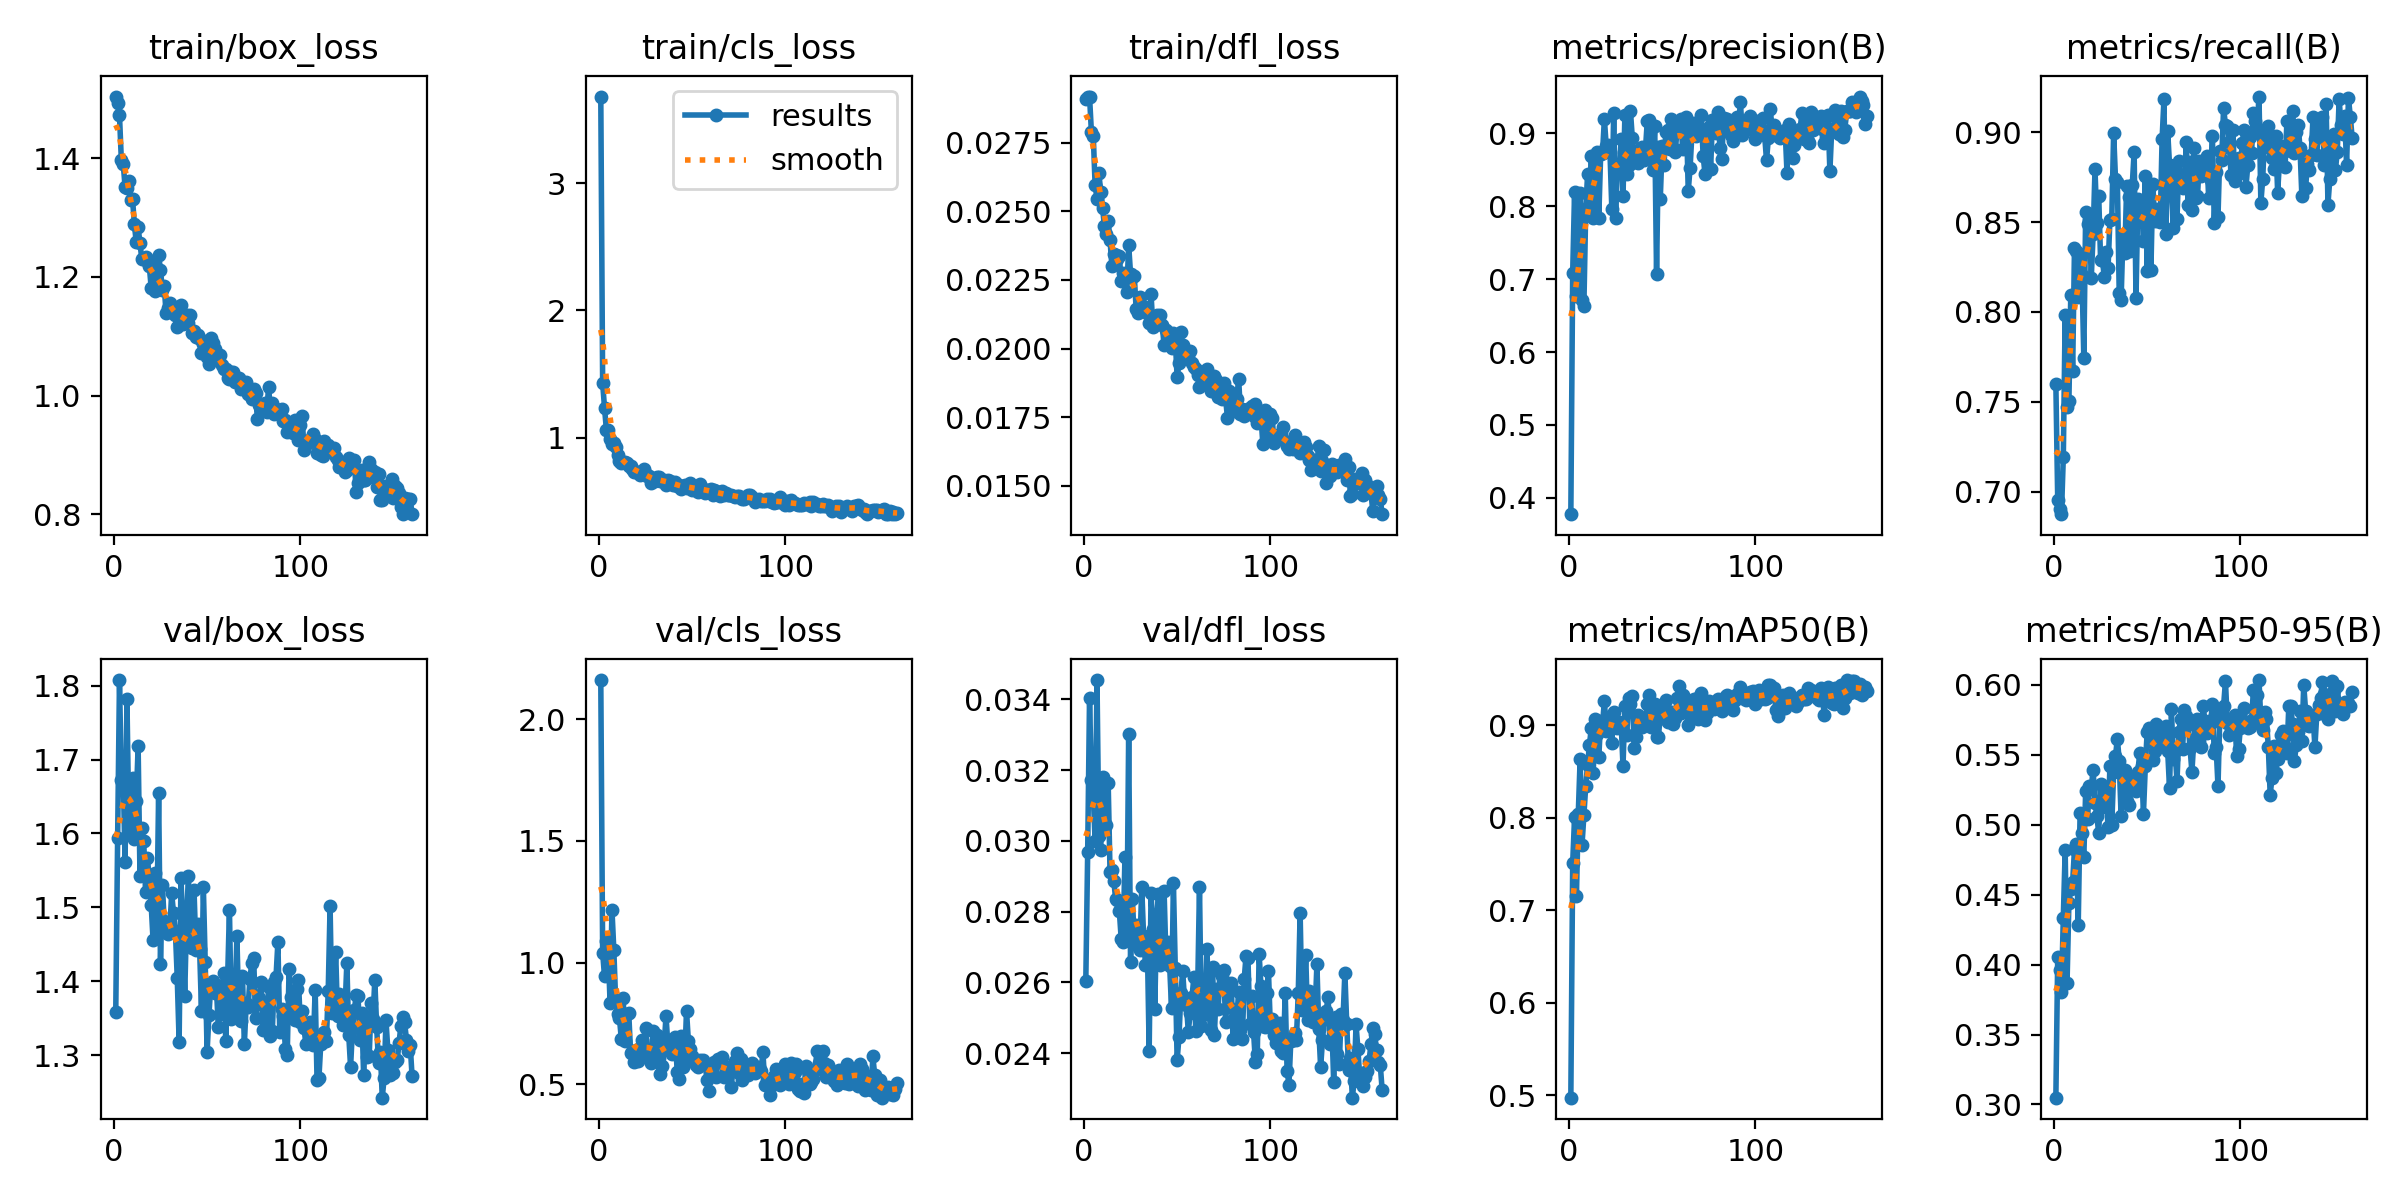

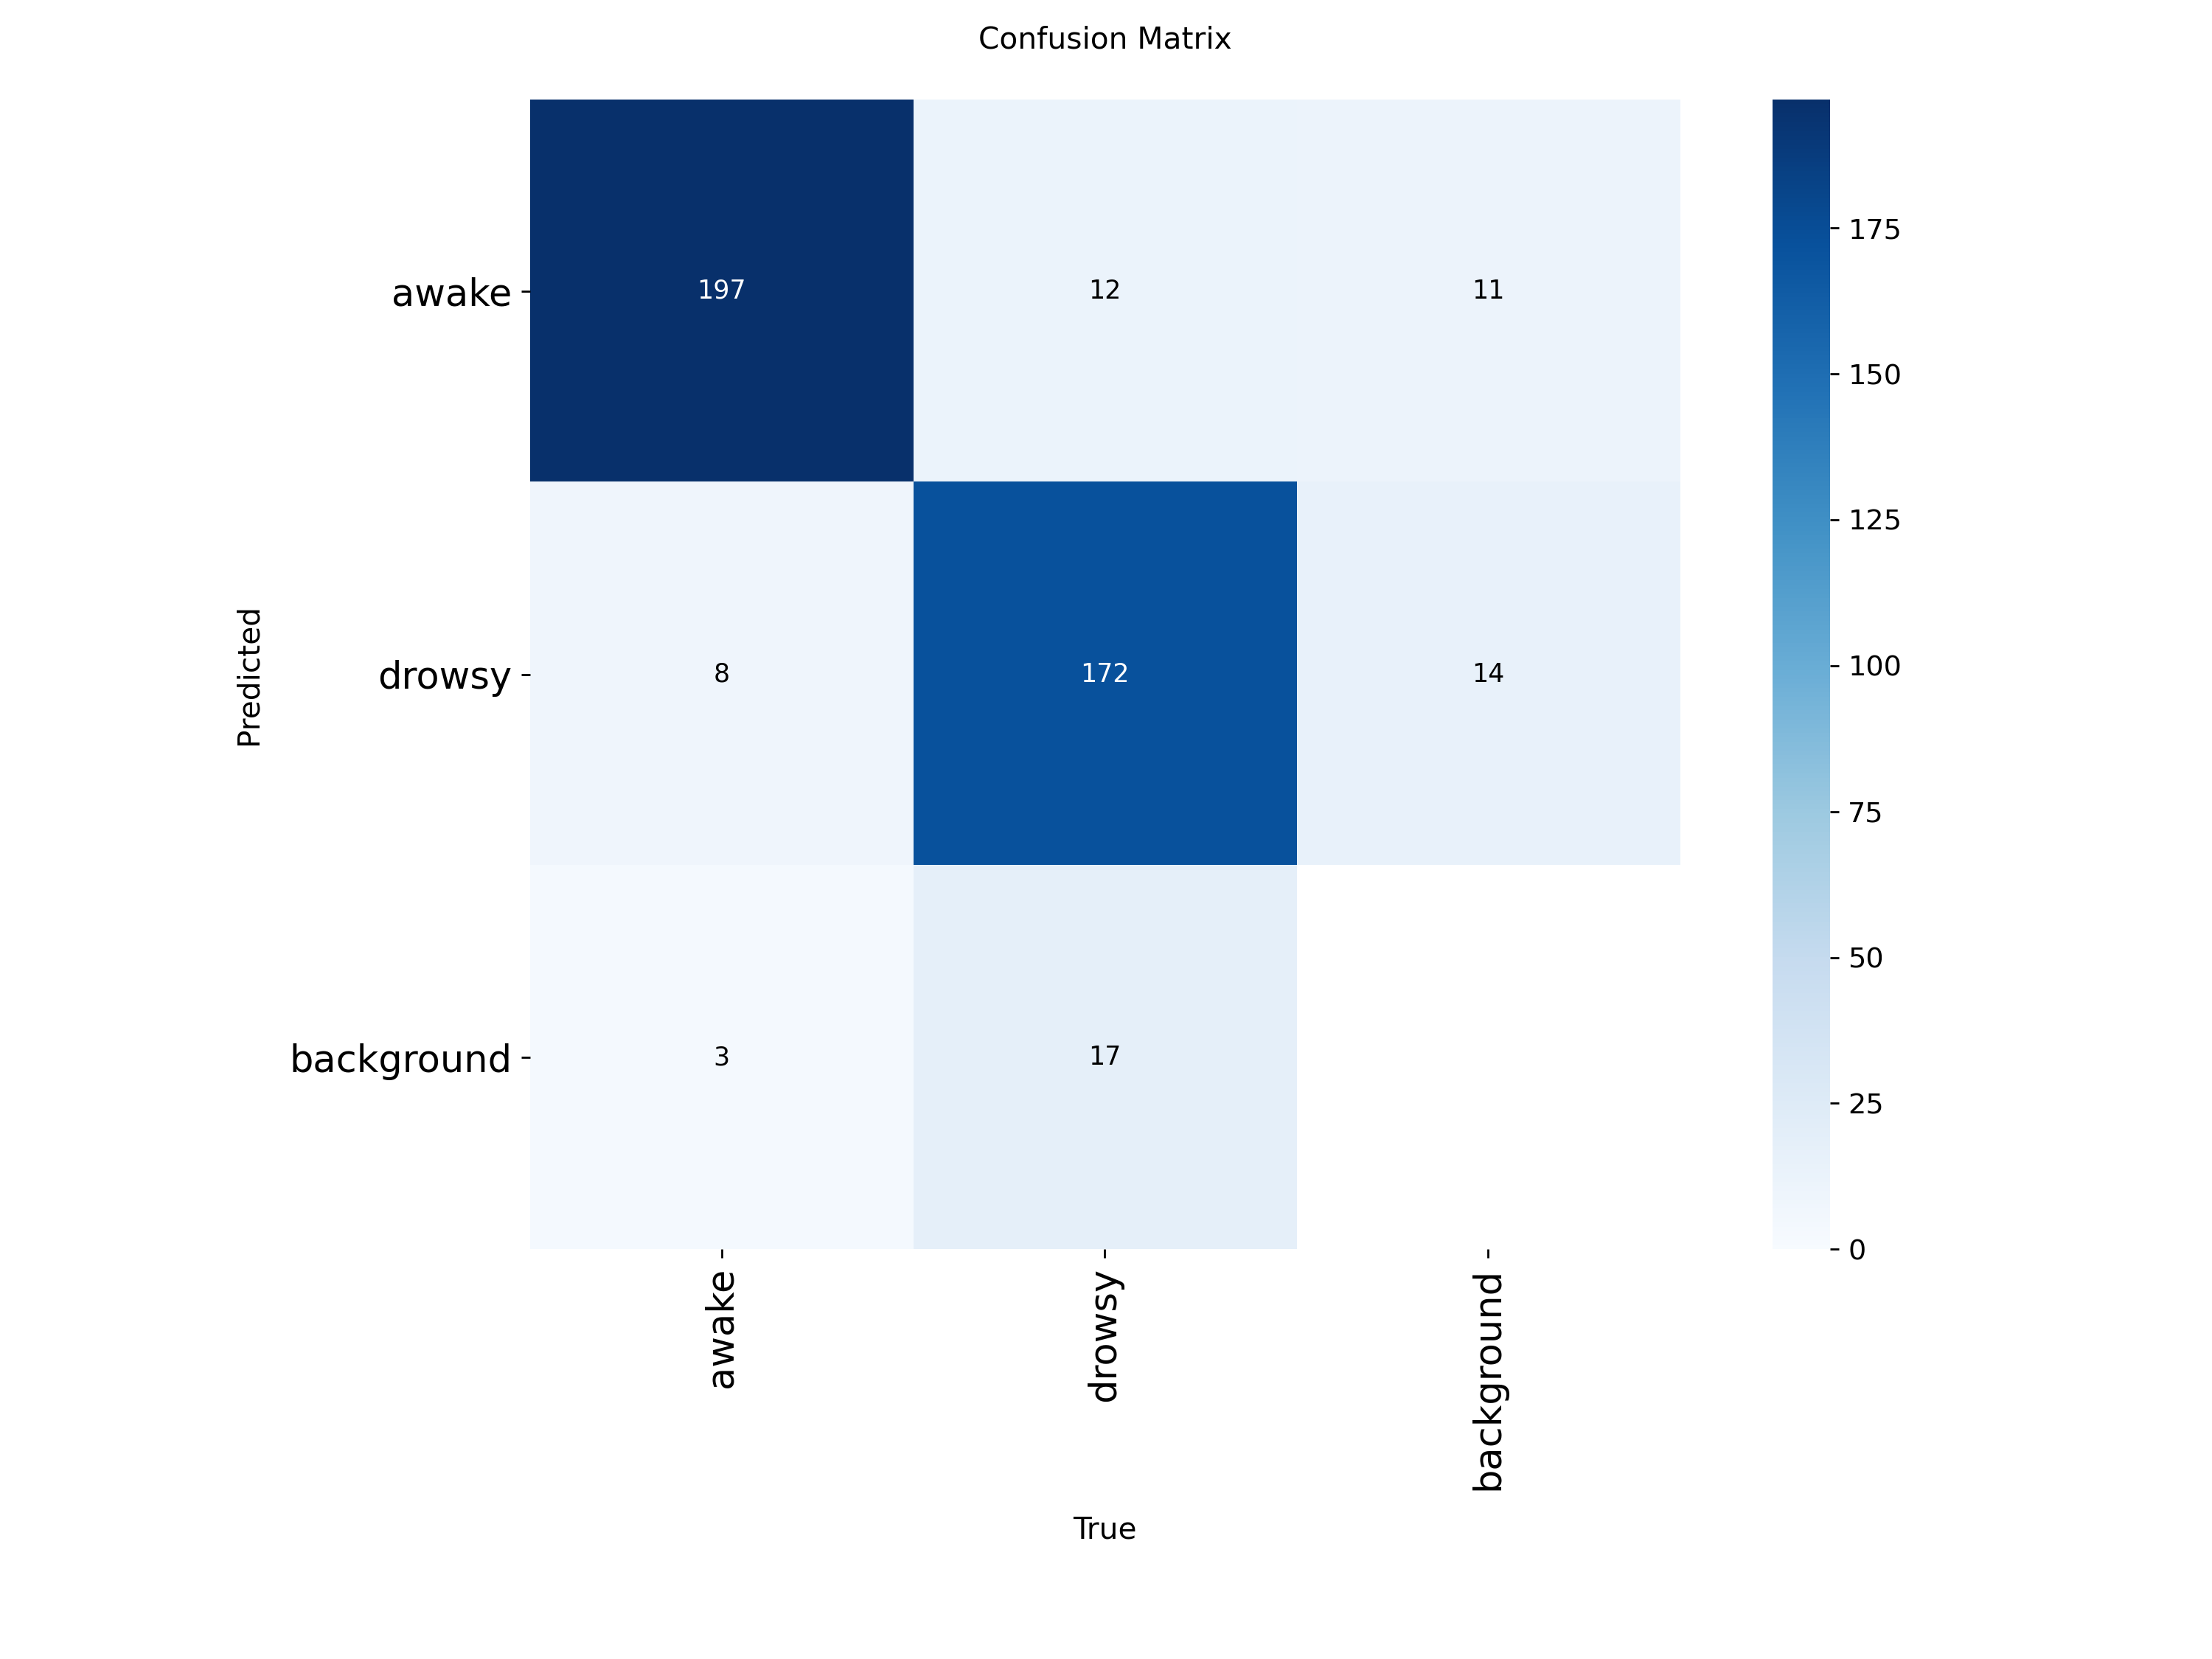

In [20]:
from IPython.display import Image, display

display(Image(filename=train_path / "results.png"))
display(Image(filename=train_path / "confusion_matrix.png"))

In [22]:
from datetime import datetime
import pandas as pd
import torch
import ultralytics

report_path = train_path / "experiment_report.txt"
results_df = pd.read_csv(train_path / "results.csv")

device_name = torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU"
amp_enabled = torch.cuda.is_available()

precision = metrics.box.mp
recall = metrics.box.mr
f1_score = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

with open(report_path, "w") as f:
    f.write("===== Experiment Report =====\n")
    f.write(f"Date              : {datetime.now()}\n")
    f.write(f"Experiment Name   : {config.NAME}\n")
    f.write(f"Train Output Path : {train_path}\n\n")

    f.write("===== Dataset =====\n")
    f.write(f"Data YAML         : {config.DATA_YAML}\n\n")

    f.write("===== Model =====\n")
    f.write(f"Model Weight      : {config.MODEL}\n")
    f.write(f"Image Size        : {config.IMG_SIZE}\n")
    f.write(f"Best Model Path   : {best_model_path}\n")
    f.write(f"Last Model Path   : {last_model_path}\n\n")

    f.write("===== Training Parameters =====\n")
    f.write(f"Epochs            : {config.EPOCHS}\n")
    f.write(f"Patience          : {config.PATIENCE}\n")
    f.write(f"Batch Size        : {config.BATCH}\n")
    f.write(f"Workers           : {config.WORKERS}\n")
    f.write(f"Seed              : {config.SEED}\n")
    f.write(f"Device            : {config.DEVICE} ({device_name})\n")
    f.write(f"AMP               : {amp_enabled}\n")
    f.write(f"Ultralytics Ver   : {ultralytics.__version__}\n")
    f.write(f"PyTorch Ver       : {torch.__version__}\n\n")

    f.write("===== Best Validation Metrics from Training =====\n")
    
    if "fitness" in results_df.columns:
        best_idx = results_df["fitness"].idxmax()
    else:
        best_idx = results_df["metrics/mAP50-95(B)"].idxmax()
    
    best_row = results_df.iloc[best_idx]
    
    f.write(f"Best Epoch                  : {int(best_row['epoch'])}\n\n")
    
    for col in results_df.columns:
        f.write(f"{col:<30}: {best_row[col]}\n")

    f.write("===== Final Test Evaluation =====\n")
    f.write(f"Precision (Box)   : {precision:.4f}\n")
    f.write(f"Recall (Box)      : {recall:.4f}\n")
    f.write(f"F1 Score          : {f1_score:.4f}\n")
    f.write(f"mAP50             : {metrics.box.map50:.4f}\n")
    f.write(f"mAP50-95          : {metrics.box.map:.4f}\n\n")

    f.write("===== Test Evaluation per Class =====\n")
    for i, name in metrics.names.items():
        class_precision = metrics.box.p[i]
        class_recall = metrics.box.r[i]
        class_f1 = (
            2 * class_precision * class_recall / (class_precision + class_recall)
            if (class_precision + class_recall) > 0
            else 0
        )

        f.write(f"\n{name}\n")
        f.write(f"  Precision       : {class_precision:.4f}\n")
        f.write(f"  Recall          : {class_recall:.4f}\n")
        f.write(f"  F1 Score        : {class_f1:.4f}\n")
        f.write(f"  mAP50           : {metrics.box.ap50[i]:.4f}\n")
        f.write(f"  mAP50-95        : {metrics.box.ap[i]:.4f}\n")

    f.write("\n===== Output Files =====\n")
    f.write(f"Results CSV       : {train_path / 'results.csv'}\n")
    f.write(f"Results Plot      : {train_path / 'results.png'}\n")
    f.write(f"Confusion Matrix  : {train_path / 'confusion_matrix.png'}\n")
    f.write(f"PR Curve          : {train_path / 'PR_curve.png'}\n")

print(f"Report saved to: {report_path}")

Report saved to: /kaggle/working/runs/detect/drowsiness_detection/v3/experiment_report.txt


In [23]:
print(report_path.read_text())

===== Experiment Report =====
Date              : 2026-06-27 11:50:33.464479
Experiment Name   : v3
Train Output Path : /kaggle/working/runs/detect/drowsiness_detection/v3

===== Dataset =====
Data YAML         : /kaggle/input/datasets/gibranariq/final-project/final_project.yolo/data.yaml

===== Model =====
Model Weight      : yolo26s.pt
Image Size        : 640
Best Model Path   : /kaggle/working/runs/detect/drowsiness_detection/v3/weights/best.pt
Last Model Path   : /kaggle/working/runs/detect/drowsiness_detection/v3/weights/last.pt

===== Training Parameters =====
Epochs            : 300
Patience          : 50
Batch Size        : 16
Workers           : 4
Seed              : 42
Device            : 0 (Tesla T4)
AMP               : True
Ultralytics Ver   : 8.4.80
PyTorch Ver       : 2.10.0+cu128

===== Best Validation Metrics from Training =====
Best Epoch                  : 110

epoch                         : 110.0
time                          : 4282.06
train/box_loss                